<a href="https://colab.research.google.com/github/AryanJadhao/CIFAR-10/blob/main/ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [36]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [37]:
X_train.shape

(50000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
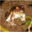

In [38]:
X_train[0]

In [39]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.resnet50 import preprocess_input

In [40]:
resize_layer = layers.Resizing(128, 128, input_shape=(32, 32, 3))


base_model = ResNet50(weights='imagenet',include_top=False, input_shape=(128,128,3))

base_model.trainable = False

model = models.Sequential([
    resize_layer,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])



model.compile(optimizer='adam',
                loss = 'sparse_categorical_crossentropy',
                metrics = ['accuracy']
              )

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_11 (Resizing)          │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,719,498 (90.48 MB)

 Trainable params: 131,786 (514.79 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [41]:
X_test.shape

(10000, 32, 32, 3)

In [42]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=8)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 107s 16ms/step - accuracy: 0.8187 - loss: 0.5498 - val_accuracy: 0.8551 - val_loss: 0.4349
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 92s 15ms/step - accuracy: 0.8897 - loss: 0.3180 - val_accuracy: 0.8800 - val_loss: 0.3605
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 92s 15ms/step - accuracy: 0.9042 - loss: 0.2713 - val_accuracy: 0.8763 - val_loss: 0.3718
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 92s 15ms/step - accuracy: 0.9160 - loss: 0.2384 - val_accuracy: 0.8901 - val_loss: 0.3446
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 92s 15ms/step - accuracy: 0.9264 - loss: 0.2072 - val_accuracy: 0.8892 - val_loss: 0.3563
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 94s 15ms/step - accuracy: 0.9315 - loss: 0.1895 - val_accuracy: 0.8850 - val_loss: 0.3982
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 93s 15ms/step - accuracy: 0.9390 - loss: 0.1710 - val_accuracy: 0.8856 - val_loss: 0.4138
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 93s 15ms/step - accuracy: 0.9454 

In [43]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8826 - loss: 0.4559


[0.45932725071907043, 0.8820000290870667]

In [50]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


In [61]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [58]:
y_pred[:5]

array([[1.35793412e-08, 3.83791211e-03, 8.52977100e-04, 8.67832363e-01,
        2.14707688e-05, 9.00536776e-03, 1.18109524e-01, 4.33321020e-06,
        8.48791478e-06, 3.27546441e-04],
       [2.79194694e-07, 6.78514189e-12, 3.30806007e-14, 6.76826640e-18,
        3.78726907e-16, 4.70550355e-22, 1.78960461e-19, 3.26518814e-18,
        9.99999762e-01, 1.97094360e-15],
       [7.59695366e-04, 3.57523654e-03, 8.38238146e-10, 1.73793011e-11,
        2.21945085e-09, 2.13301870e-15, 1.43999721e-12, 5.58405856e-11,
        9.95664835e-01, 2.36854248e-07],
       [8.09581637e-01, 2.60379185e-09, 1.83252275e-01, 5.12899272e-03,
        5.40391600e-04, 5.65884751e-04, 4.17967101e-07, 5.14132626e-06,
        9.25349130e-04, 1.31115230e-10],
       [2.35361536e-10, 1.26773952e-10, 4.82869887e-04, 2.07949648e-04,
        2.76802137e-04, 7.15535361e-06, 9.99024630e-01, 5.47004277e-07,
        4.04521347e-11, 1.77326417e-10]], dtype=float32)

In [60]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]